https://docs.ultralytics.com/guides/sahi-tiled-inference/#how-do-i-handle-large-scale-inference-projects-using-yolov8-and-sahi




SAHI (Slicing Aided Hyper Inference) is an innovative library designed to optimize object detection algorithms for large-scale and high-resolution imagery. Its core functionality lies in partitioning images into manageable slices, running object detection on each slice, and then stitching the results back together. SAHI is compatible with a range of object detection models, including the YOLO series, thereby offering flexibility while ensuring optimized use of computational resources.

Key Features of SAHI

    Seamless Integration: SAHI integrates effortlessly with YOLO models, meaning you can start slicing and detecting without a lot of code modification.
    Resource Efficiency: By breaking down large images into smaller parts, SAHI optimizes the memory usage, allowing you to run high-quality detection on hardware with limited resources.
    High Accuracy: SAHI maintains the detection accuracy by employing smart algorithms to merge overlapping detection boxes during the stitching process.


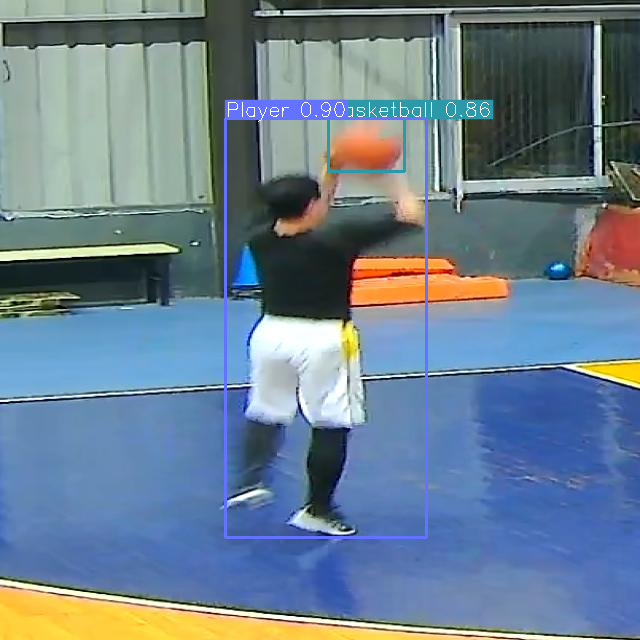

In [1]:
from sahi.utils.yolov8 import download_yolov8s_model
from sahi.predict import get_sliced_prediction
from sahi import AutoDetectionModel
import os
from sahi.predict import get_prediction
from IPython.display import Image

# Download the YOLOv8 model
yolov8_model_path = "runs/detect/train/weights/best.pt"
if not os.path.exists(yolov8_model_path):
    download_yolov8s_model(yolov8_model_path)

# Set up the model for detection
detection_model = AutoDetectionModel.from_pretrained(
    model_type="yolov8",
    model_path=yolov8_model_path,
    confidence_threshold=0.3,
    device="cuda"  # Switch to "cpu" if you're not using a GPU
)


# With an image path
result = get_prediction("../data/images/basketball-and-hoop-12/test/images/-_20230317104113_png.rf.9629016382d53426f73dcc89eb5b764d.jpg", detection_model)

Image("../data/images/results/prediction_visual.png")
# With a numpy image
# result = get_prediction(read_image("demo_data/small-vehicles1.jpeg"), detection_model)



# Sliced Inference with YOLOv8

Perform sliced inference by specifying the slice dimensions and overlap ratios:

Performing prediction on 9 slices.
Prediction complete. Visuals exported.


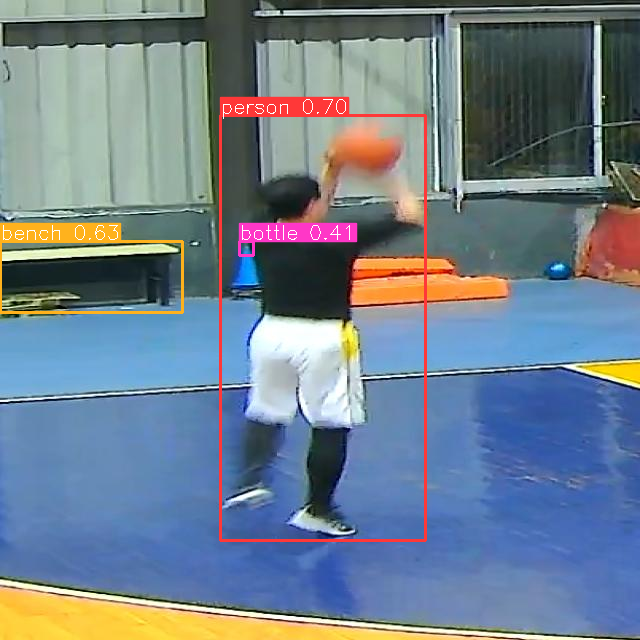

In [2]:
from sahi.utils.yolov8 import download_yolov8s_model
from sahi.predict import get_sliced_prediction
from sahi import AutoDetectionModel
import os
from sahi.predict import get_prediction
from IPython.display import Image

# Download the YOLOv8 model
yolov8_model_path = "runs/detect/train2/weights/best.pt"
if not os.path.exists(yolov8_model_path):
    download_yolov8s_model(yolov8_model_path)

# Set up the model for detection
detection_model = AutoDetectionModel.from_pretrained(
    model_type="yolov8",
    model_path=yolov8_model_path,
    confidence_threshold=0.3,
    device="cuda"  # Switch to "cpu" if you're not using a GPU
)


# Perform sliced inference
result = get_sliced_prediction(
    "../data/images/basketball-and-hoop-12/test/images/-_20230317104113_png.rf.9629016382d53426f73dcc89eb5b764d.jpg",  # Path to your test image
    detection_model,
    slice_height=256,  # Customize slice height and width
    slice_width=256,
    overlap_height_ratio=0.2,  # Adjust overlap ratio for better accuracy
    overlap_width_ratio=0.2
)

# Export the prediction visuals
result.export_visuals(export_dir="../data/images/results")
print("Prediction complete. Visuals exported.")

Image("../data/images/results/prediction_visual.png")

# Handling Prediction Results

# SAHI provides a PredictionResult object, which can be converted into various annotation formats:

# # Access the object prediction list
# object_prediction_list = result.object_prediction_list

# # Convert to COCO annotation, COCO prediction, imantics, and fiftyone formats
# result.to_coco_annotations()[:3]
# result.to_coco_predictions(image_id=1)[:3]
# result.to_imantics_annotations()[:3]
# result.to_fiftyone_detections()[:3]

# Batch Prediction

For batch prediction on a directory of images:

In [3]:
from sahi.predict import predict

# source can be video or file of images

predict(
    model_type="yolov8",
    model_path="runs/detect/train2/weights/best.pt",
    model_device="cuda",  # or 'cpu'
    model_confidence_threshold=0.4,
    source="../data/videos/downloaded/downloaded_video.mp4", # "../data/images/basketball-and-hoop-12/test/images", 
    slice_height=256,
    slice_width=256,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2,
    project="../data/images/results/sahi",  # Specify where to save the results
    name="batch_predictions",  # Name of the folder within the project folder
    
)

Performing inference on video frames:   9%|▉         | 395/4478 [04:53<57:02,  1.19it/s]

Prediction time is: 518.69 ms


Performing inference on video frames:   9%|▉         | 395/4478 [04:53<57:02,  1.19it/s]

Performing prediction on 60 slices.


Performing inference on video frames:   9%|▉         | 396/4478 [04:54<57:45,  1.18it/s]

...

Prediction time is: 579.87 ms
Performing prediction on 60 slices.


Performing inference on video frames:  21%|██▏       | 961/4478 [11:23<43:15,  1.35it/s]

Prediction time is: 548.95 ms
Performing prediction on 60 slices.


Performing inference on video frames:  21%|██▏       | 962/4478 [11:23<43:13,  1.36it/s]

Prediction time is: 567.93 ms
Performing prediction on 60 slices.


https://github.com/AhmedIbrahimai/SAHI-and-YOLO8-in-real-time/blob/main/yolov8_sahi_demo.py